# EJERCICIOS PRÁCTICOS

## SETUP PARA LOS EJERCICIOS

In [25]:
import torch
import torch.nn as nn
import torchvision
import torchmetrics 
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader
import copy
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
    

In [33]:
def _move_to_device(x, device):
    if isinstance(x, dict):
        return {k: v.to(device, non_blocking=True) for k, v in x.items()}
    return x.to(device, non_blocking=True)


def evaluate_tm(model, data_loader, metric, device):
    model.eval()
    metric.reset()

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = _move_to_device(X_batch, device)
            y_batch = _move_to_device(y_batch, device)

            # Forward compatible con tensor o dict
            if isinstance(X_batch, dict):
                y_pred, _ = model(X_batch["X_wide"], X_batch["X_deep"])
            else:
                y_pred = model(X_batch)

            # Binario: salida [B,1] o [B] -> sigmoid + threshold
            if y_pred.ndim == 2 and y_pred.size(1) == 1:
                y_pred = torch.sigmoid(y_pred)
                y_pred = (y_pred >= 0.5).int()
                if y_batch.ndim == 1:
                    y_batch = y_batch.unsqueeze(1)
                y_batch = y_batch.int()

            # Multiclase: salida [B,C] -> argmax
            elif y_pred.ndim == 2 and y_pred.size(1) > 1:
                y_pred = torch.argmax(y_pred, dim=1)
                y_batch = y_batch.long()

            # Caso raro [B] binario
            else:
                y_pred = (torch.sigmoid(y_pred) >= 0.5).int()
                y_batch = y_batch.int()

            metric.update(y_pred, y_batch)

    return metric.compute()


def eval_set (model, dataset, device, eval_func = False):

    if not eval_func:
        acc = BinaryAccuracy().to(device)
    
    
    tm_eval = evaluate_tm(model, dataset, eval_func, device)
    print("Accuracy:", tm_eval.item())

   

def _prepare_for_loss(y_pred, y_true, criterion):
    """
    Ajusta shapes/dtypes según la loss:
    - BCEWithLogitsLoss: input y target misma forma (normalmente [B,1]), target float
    - CrossEntropyLoss: y_pred [B,C], y_true [B] long
    """
    if isinstance(criterion, torch.nn.BCEWithLogitsLoss):
        # y_pred esperado [B,1] o [B]
        if y_pred.ndim == 2 and y_pred.size(1) == 1 and y_true.ndim == 1:
            y_true = y_true.unsqueeze(1)  # [B] -> [B,1]
        y_true = y_true.float()
    else:
        # Caso típico multiclase
        y_true = y_true.long()

    return y_pred, y_true


def _batch_accuracy_percent(y_pred, y_true, criterion):
    """
    Accuracy en porcentaje para imprimir por época.
    """
    if isinstance(criterion, torch.nn.BCEWithLogitsLoss):
        # Binario con logits
        probs = torch.sigmoid(y_pred)
        preds = (probs >= 0.5).long()

        if y_true.ndim == 1:
            y_true = y_true.unsqueeze(1)
        y_true = y_true.long()

        correct = (preds == y_true).sum().item()
        total = y_true.numel()
    else:
        # Multiclase
        preds = torch.argmax(y_pred, dim=1)
        y_true = y_true.long()
        correct = (preds == y_true).sum().item()
        total = y_true.size(0)

    return correct, total


def train_minibatch_gd(
    model, optimizer, criterion, train_loader, eval_loader,
    n_epochs, device, eval_func=False, min_delta=0.002, patience=6
):
    # Early stopping:
    # min_delta: mejora mínima exigida en val_loss para considerar que realmente mejoró
    # patience: número de épocas consecutivas sin mejora significativa antes de parar
    best_val_loss = float("inf")
    patience_counter = 0

    # Guardamos el mejor estado del modelo para restaurarlo al final
    best_state = copy.deepcopy(model.state_dict())

    eval_calc = None

    for epoch in range(n_epochs):
        # Para diferenciar los diferentes modos de un entrenamiento tenemos model.train() y model.eval()

        # model.train(): Activa comportamiento de entrenamiento:
        #     Dropout: apaga neuronas aleatoriamente.
        #     BatchNorm: usa estadísticas del batch actual y actualiza medias/varianzas internas.
        # Se usa antes del loop de entrenamiento.
        model.train()

        # -------- TRAIN --------
        total_loss = 0.0
        total_train_samples = 0

        for X_batch, y_batch in train_loader:
            # Para mover mas rapido a la GPU los batches, utilizar non_blocking=True
            # para no bloquear el hilo principal
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            # Poner gradientes a cero antes del backward para evitar acumulación
            optimizer.zero_grad()

            y_pred = model(X_batch)

            # Ajustamos shapes/dtypes según la loss:
            # - BCEWithLogitsLoss: y_pred/y_true misma forma (p.ej. [B,1]) y target float
            # - CrossEntropyLoss: y_true tipo long con forma [B]
            y_pred, y_batch_loss = _prepare_for_loss(y_pred, y_batch, criterion)
            loss = criterion(y_pred, y_batch_loss)

            loss.backward()
            optimizer.step()

            # Acumulamos pérdida ponderada por tamaño de batch
            bs = y_batch.size(0)
            total_loss += loss.item() * bs
            total_train_samples += bs

        mean_loss = total_loss / total_train_samples
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {mean_loss:.4f}")

        # model.eval(): Activa comportamiento de inferencia/validación:
        #     Dropout: se desactiva.
        #     BatchNorm: usa estadísticas acumuladas, no las del batch.
        # Se usa para validación/test/inferencia.
        model.eval()

        # Evaluación sobre train para monitorizar (opcional)
        if not eval_func:
            eval_set(model, train_loader, device)
        else:
            eval_set(model, train_loader, device, eval_func)

        # -------- VALIDATION (end of epoch) --------
        val_loss_sum = 0.0
        total_val_samples = 0

        # Para accuracy de validación (%)
        total_correct = 0
        total_items = 0

        # El modo eval no desactiva gradientes, hay que seguir explicitando esta restricción
        with torch.no_grad():
            for X_val, y_val in eval_loader:
                X_val = X_val.to(device, non_blocking=True)
                y_val = y_val.to(device, non_blocking=True)

                y_val_pred = model(X_val)

                # Mismo ajuste de shapes/dtypes que en entrenamiento
                y_val_pred, y_val_loss = _prepare_for_loss(y_val_pred, y_val, criterion)
                vloss = criterion(y_val_pred, y_val_loss)

                # Acumulamos pérdida ponderada por tamaño de batch para cálculo más correcto
                bs = y_val.size(0)
                val_loss_sum += vloss.item() * bs
                total_val_samples += bs

                # Cálculo de acierto para mostrar porcentaje de validación
                c, t = _batch_accuracy_percent(y_val_pred, y_val, criterion)
                total_correct += c
                total_items += t

        mean_val_loss = val_loss_sum / total_val_samples
        val_acc_pct = 100.0 * total_correct / total_items if total_items > 0 else 0.0
        print(f"Epoch {epoch + 1}/{n_epochs}, Val Loss: {mean_val_loss:.4f}, Val Acc: {val_acc_pct:.2f}%")

        if not eval_func:
            eval_calc = eval_set(model, eval_loader, device)
        else:
            eval_calc = eval_set(model, eval_loader, device, eval_func)

        # Early stopping sobre val_loss:
        # Solo consideramos mejora si baja al menos min_delta respecto al mejor valor histórico
        if mean_val_loss < (best_val_loss - min_delta):
            best_val_loss = mean_val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"EarlyStopping: {patience_counter}/{patience} sin mejora significativa")

            if patience_counter >= patience:
                print(f"Parada por early stopping. Mejor val_loss: {best_val_loss:.4f}")
                break
    # Restauramos el mejor modelo encontrado durante el entrenamiento
    model.load_state_dict(best_state)
    return eval_calc


## 8. Construye tu propia CNN desde cero e intenta lograr la mayor precisión posible en MNIST.


#### Dataset de imagenes en blanco y negro; numeros del 0-9 28x28

In [9]:
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.MNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.MNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

In [10]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [37]:
class ModeloMINSTFCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cn_model = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 2),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 1, 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 10, 1), # Convolucional 1x1 unicamente para reducir los canales al nº de clases
        )
        for mod in self.cn_model:
            if isinstance(mod, nn.Conv2d):
                nn.init.kaiming_normal_(mod.weight, nonlinearity="relu")
                if mod.bias is not None:
                    nn.init.zeros_(mod.bias)
                    
        self.gap = nn.AdaptiveAvgPool2d(1)  # Global Average Pooling para reducir a 1 la salida

    def forward(self, x):
        x = self.cn_model(x)
        x = self.gap(x)          # (batch, num_classes, 1, 1)
        return x.flatten(1)      # (batch, num_classes)

In [45]:
class ModeloMINSTDENSE(nn.Module):
    def __init__(self):
        super().__init__()
        self.cn_model = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 2),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 1, 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(64 * 16 * 16, 128), 
            nn.Dropout(0.5),
            nn.Linear(128, 10),
        )
        for mod in self.cn_model:
            if isinstance(mod, nn.Conv2d):
                nn.init.kaiming_normal_(mod.weight, nonlinearity="relu")
                if mod.bias is not None:
                    nn.init.zeros_(mod.bias)
                    

    def forward(self, x):
        return self.cn_model(x)      # (batch, num_classes)

In [49]:
torch.manual_seed(42)
modelo = ModeloMINSTFCN().to(device)
modelo2 = ModeloMINSTDENSE().to(device)
optimizer = torch.optim.AdamW(modelo.parameters(), lr=1e-3, weight_decay=1e-4)
optimizer2 = torch.optim.AdamW(modelo2.parameters(), lr=1e-3, weight_decay=1e-4)


In [43]:
n_iter = 20

xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass",num_classes=10).to(device)
res = train_minibatch_gd(
    modelo, optimizer, xentropy, train_loader, valid_loader,
    n_iter, device, eval_func=accuracy, min_delta=0.002, patience=6
)


Epoch 1/20, Loss: 0.2168
Accuracy: 0.9364181756973267
Epoch 1/20, Val Loss: 0.2146, Val Acc: 93.00%
Accuracy: 0.9300000071525574
Epoch 2/20, Loss: 0.2109
Accuracy: 0.9430181980133057
Epoch 2/20, Val Loss: 0.1958, Val Acc: 94.06%
Accuracy: 0.9405999779701233
Epoch 3/20, Loss: 0.2078
Accuracy: 0.932309091091156
Epoch 3/20, Val Loss: 0.2224, Val Acc: 93.02%
Accuracy: 0.9301999807357788
EarlyStopping: 1/6 sin mejora significativa
Epoch 4/20, Loss: 0.2030
Accuracy: 0.9382908940315247
Epoch 4/20, Val Loss: 0.2064, Val Acc: 93.54%
Accuracy: 0.9354000091552734
EarlyStopping: 2/6 sin mejora significativa
Epoch 5/20, Loss: 0.1991
Accuracy: 0.9437454342842102
Epoch 5/20, Val Loss: 0.1995, Val Acc: 93.78%
Accuracy: 0.9377999901771545
EarlyStopping: 3/6 sin mejora significativa
Epoch 6/20, Loss: 0.1947
Accuracy: 0.9364727139472961
Epoch 6/20, Val Loss: 0.2148, Val Acc: 93.04%
Accuracy: 0.930400013923645
EarlyStopping: 4/6 sin mejora significativa
Epoch 7/20, Loss: 0.1912
Accuracy: 0.947109103202819

In [50]:
res = train_minibatch_gd(
    modelo2, optimizer2, xentropy, train_loader, valid_loader,
    n_iter, device, eval_func=accuracy, min_delta=0.002, patience=6
)

Epoch 1/20, Loss: 0.1529
Accuracy: 0.9870181679725647
Epoch 1/20, Val Loss: 0.0586, Val Acc: 98.36%
Accuracy: 0.9836000204086304
Epoch 2/20, Loss: 0.0682
Accuracy: 0.990818202495575
Epoch 2/20, Val Loss: 0.0576, Val Acc: 98.36%
Accuracy: 0.9836000204086304
EarlyStopping: 1/6 sin mejora significativa
Epoch 3/20, Loss: 0.0497
Accuracy: 0.9939091205596924
Epoch 3/20, Val Loss: 0.0493, Val Acc: 98.64%
Accuracy: 0.9864000082015991
Epoch 4/20, Loss: 0.0421
Accuracy: 0.9941090941429138
Epoch 4/20, Val Loss: 0.0593, Val Acc: 98.46%
Accuracy: 0.9846000075340271
EarlyStopping: 1/6 sin mejora significativa
Epoch 5/20, Loss: 0.0379
Accuracy: 0.9966182112693787
Epoch 5/20, Val Loss: 0.0475, Val Acc: 98.62%
Accuracy: 0.9861999750137329
EarlyStopping: 2/6 sin mejora significativa
Epoch 6/20, Loss: 0.0310
Accuracy: 0.996254563331604
Epoch 6/20, Val Loss: 0.0597, Val Acc: 98.56%
Accuracy: 0.9855999946594238
EarlyStopping: 3/6 sin mejora significativa
Epoch 7/20, Loss: 0.0282
Accuracy: 0.997381806373596

In [54]:
fcn_params = sum(p.numel() for p in modelo.parameters())
dense_params = sum(p.numel() for p in modelo2.parameters())
print(f"Parametros de modelo FCN: {fcn_params}")
print(f"Parametros de modelo con capas densas: {dense_params}")
print(f"Diferencia de parametros entre modelos: { dense_params - fcn_params} \nRatio de parametros: { dense_params/fcn_params}")

Parametros de modelo FCN: 19466
Parametros de modelo con capas densas: 2117386
Diferencia de parametros entre modelos: 2097920 
Ratio de parametros: 108.77355388883181


## 9. Utiliza el aprendizaje por transferencia (transfer learning) para la clasificación de imágenes a gran escala, siguiendo estos pasos: (Esto se aplicará en el repo ReconocimientoComponentes para mejorar un antiguo proyecto)

### a. Crea un conjunto de entrenamiento que contenga al menos 100 imágenes por clase. Por ejemplo, podrías clasificar tus propias fotos según la ubicación (playa, montaña, ciudad, etc.). Alternativamente, puedes usar un conjunto de datos existente, como el utilizado en el tutorial de PyTorch sobre transfer learning para visión por computadora.


### b. Divídelo en un conjunto de entrenamiento, un conjunto de validación y un conjunto de prueba.

### c. Construye el pipeline de entrada, aplica las operaciones de preprocesamiento adecuadas y, opcionalmente, añade aumento de datos (data augmentation).


### d. Ajusta finamente (fine-tune) un modelo preentrenado con este conjunto de datos.


## 10. Realiza el tutorial de PyTorch sobre ajuste fino (fine-tuning) para detección de objetos. [ https://homl.info/detectiontuto ]

### Writing a custom dataset for PennFudan

/home/danielbb/Documentos/Proyectos/ML-Roadmap/ApuntesML/Practica/NN_DL/12_CV_CNN/Ejercicios/datasets/Penn/data/PennFudanPed/PNGImages


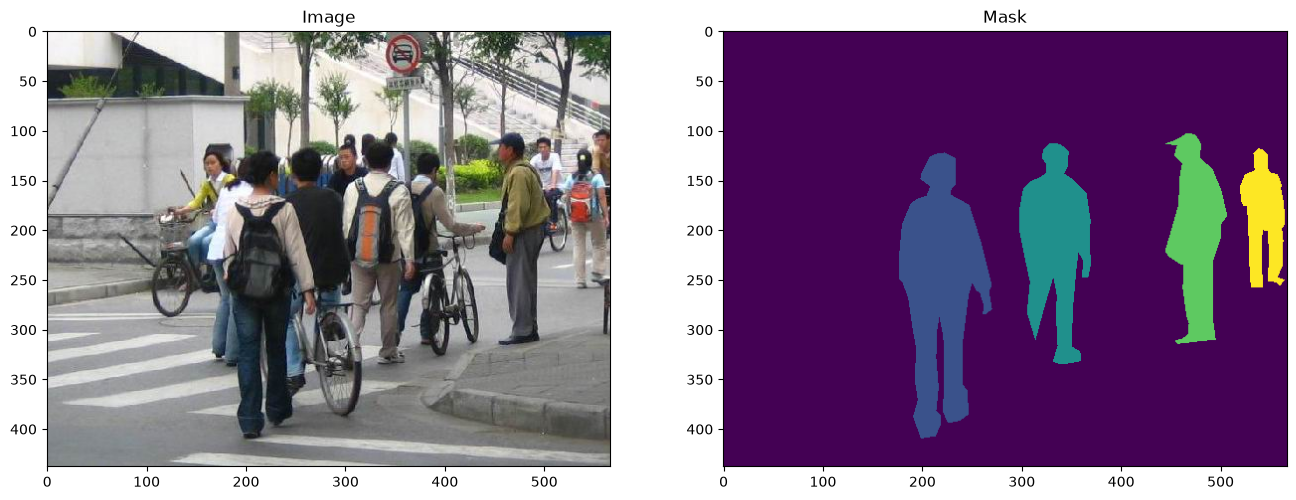

In [70]:
import matplotlib.pyplot as plt
from torchvision.io import read_image
import os 

print(os.path.abspath("datasets/Penn/data/PennFudanPed/PNGImages"))
base_path = "/home/danielbb/Documentos/Proyectos/ML-Roadmap/ApuntesML/Practica/NN_DL/12_CV_CNN/Ejercicios/datasets/Penn/"
image = read_image(base_path + "data/PennFudanPed/PNGImages/FudanPed00046.png")
mask = read_image(base_path + "data/PennFudanPed/PedMasks/FudanPed00046_mask.png")

plt.figure(figsize=(16, 8))
plt.subplot(121)
plt.title("Image")
plt.imshow(image.permute(1, 2, 0))
plt.subplot(122)
plt.title("Mask")
plt.imshow(mask.permute(1, 2, 0))

In [71]:
import os
import torch

from torchvision.io import read_image
from torchvision.ops.boxes import masks_to_boxes
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F


class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms):
        self.root = root
        self.transforms = transforms
        # load all image files, sorting them to
        # ensure that they are aligned
        self.imgs = list(sorted(os.listdir(os.path.join(root, "PNGImages"))))
        self.masks = list(sorted(os.listdir(os.path.join(root, "PedMasks"))))

    def __getitem__(self, idx):
        # load images and masks
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])
        img = read_image(img_path)
        mask = read_image(mask_path)
        # instances are encoded as different colors
        obj_ids = torch.unique(mask)
        # first id is the background, so remove it
        obj_ids = obj_ids[1:]
        num_objs = len(obj_ids)

        # split the color-encoded mask into a set
        # of binary masks
        masks = (mask == obj_ids[:, None, None]).to(dtype=torch.uint8)

        # get bounding box coordinates for each mask
        boxes = masks_to_boxes(masks)

        # there is only one class
        labels = torch.ones((num_objs,), dtype=torch.int64)

        image_id = idx
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        # suppose all instances are not crowd
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        # Wrap sample and targets into torchvision tv_tensors:
        img = tv_tensors.Image(img)

        target = {}
        target["boxes"] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=F.get_size(img))
        target["masks"] = tv_tensors.Mask(masks)
        target["labels"] = labels
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.imgs)

### Defining your model


#### 1 - Finetuning from a pretrained model

In [72]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# load a model pre-trained on COCO
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

# replace the classifier with a new one, that has
# num_classes which is user-defined
num_classes = 2  # 1 class (person) + background
# get number of input features for the classifier
in_features = model.roi_heads.box_predictor.cls_score.in_features
# replace the pre-trained head with a new one
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

1.3%

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /home/danielbb/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100.0%


#### 2 - Modifying the model to add a different backbone

In [ ]:
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator

# load a pre-trained model for classification and return
# only the features
backbone = torchvision.models.mobilenet_v2(weights="DEFAULT").features
# ``FasterRCNN`` needs to know the number of
# output channels in a backbone. For mobilenet_v2, it's 1280
# so we need to add it here
backbone.out_channels = 1280

# let's make the RPN generate 5 x 3 anchors per spatial
# location, with 5 different sizes and 3 different aspect
# ratios. We have a Tuple[Tuple[int]] because each feature
# map could potentially have different sizes and
# aspect ratios
anchor_generator = AnchorGenerator(
    sizes=((32, 64, 128, 256, 512),),
    aspect_ratios=((0.5, 1.0, 2.0),)
)

# let's define what are the feature maps that we will
# use to perform the region of interest cropping, as well as
# the size of the crop after rescaling.
# if your backbone returns a Tensor, featmap_names is expected to
# be [0]. More generally, the backbone should return an
# ``OrderedDict[Tensor]``, and in ``featmap_names`` you can choose which
# feature maps to use.
roi_pooler = torchvision.ops.MultiScaleRoIAlign(
    featmap_names=['0'],
    output_size=7,
    sampling_ratio=2
)

# put the pieces together inside a Faster-RCNN model
model = FasterRCNN(
    backbone,
    num_classes=2,
    rpn_anchor_generator=anchor_generator,
    box_roi_pool=roi_pooler
)

### Object detection and instance segmentation model for PennFudan Dataset

In [76]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor


def get_model_instance_segmentation(num_classes):
    # load an instance segmentation model pre-trained on COCO
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

    # get number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # now get the number of input features for the mask classifier
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    # and replace the mask predictor with a new one
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask,
        hidden_layer,
        num_classes
    )

    return model

In [81]:
from torchvision.transforms import v2 as T


def get_transform(train):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)

In [90]:
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_utils.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_eval.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/transforms.py")

--2026-09-01 18:04:29--  https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py
Cargado certificado CA '/etc/ssl/certs/ca-certificates.crt'
Resolviendo raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8003::154, 2606:50c0:8001::154, 2606:50c0:8000::154, ...
Conectando con raw.githubusercontent.com (raw.githubusercontent.com)[2606:50c0:8003::154]:443... conectado.
Petición HTTP enviada, esperando respuesta... 200 OK
Longitud: 4063 (4,0K) [text/plain]
Grabando a: ‘engine.py.1’

     0K ...                                                   100%  114M=0s

2026-09-01 18:04:29 (114 MB/s) - ‘engine.py.1’ guardado [4063/4063]

--2026-09-01 18:04:29--  https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py
Cargado certificado CA '/etc/ssl/certs/ca-certificates.crt'
Resolviendo raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8003::154, 2606:50c0:8000::154, 2606:50c0:8001::154, ...
Conectando con raw.g

0

### Testing forward() method

In [93]:
import utils

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
dataset = PennFudanDataset(base_path + 'data/PennFudanPed', get_transform(train=True))
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=utils.collate_fn
)

# For Training
images, targets = next(iter(data_loader))
images = list(image for image in images)
targets = [{k: v for k, v in t.items()} for t in targets]
output = model(images, targets)  # Returns losses and detections
print(output)

# For inference
model.eval()
x = [torch.rand(3, 300, 400), torch.rand(3, 500, 400)]
predictions = model(x)  # Returns predictions
print(predictions[0])

{'loss_classifier': tensor(0.2156, grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0457, grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0750, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0137, grad_fn=<DivBackward0>)}
{'boxes': tensor([], size=(0, 4), grad_fn=<StackBackward0>), 'labels': tensor([], dtype=torch.int64), 'scores': tensor([], grad_fn=<IndexBackward0>)}


In [95]:
from engine import train_one_epoch, evaluate

# train on the accelerator or on the CPU, if an accelerator is not available
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device('cpu')

# our dataset has two classes only - background and person
num_classes = 2
# use our dataset and defined transformations
dataset = PennFudanDataset(base_path + 'data/PennFudanPed', get_transform(train=True))
dataset_test = PennFudanDataset(base_path + 'data/PennFudanPed', get_transform(train=False))

# split the dataset in train and test set
indices = torch.randperm(len(dataset)).tolist()
dataset = torch.utils.data.Subset(dataset, indices[:-50])
dataset_test = torch.utils.data.Subset(dataset_test, indices[-50:])

# define training and validation data loaders
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=utils.collate_fn
)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=1,
    shuffle=False,
    collate_fn=utils.collate_fn
)

# get the model using our helper function
model = get_model_instance_segmentation(num_classes)

# move model to the right device
model.to(device)

# construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

# and a learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

# let's train it just for 2 epochs
num_epochs = 2

for epoch in range(num_epochs):
    # train for one epoch, printing every 10 iterations
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=10)
    # update the learning rate
    lr_scheduler.step()
    # evaluate on the test dataset
    evaluate(model, data_loader_test, device=device)

print("That's it!")

2.9%

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /home/danielbb/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100.0%
/home/danielbb/Documentos/Proyectos/ML-Roadmap/ApuntesML/Practica/NN_DL/12_CV_CNN/Ejercicios/engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [ 0/61]  eta: 0:00:38  lr: 0.000088  loss: 3.2344 (3.2344)  loss_classifier: 0.4116 (0.4116)  loss_box_reg: 0.1348 (0.1348)  loss_mask: 2.5272 (2.5272)  loss_objectness: 0.1408 (0.1408)  loss_rpn_box_reg: 0.0199 (0.0199)  time: 0.6284  data: 0.0116  max mem: 1922
Epoch: [0]  [10/61]  eta: 0:00:17  lr: 0.000921  loss: 2.3968 (2.3574)  loss_classifier: 0.3287 (0.2827)  loss_box_reg: 0.1090 (0.1077)  loss_mask: 2.0029 (1.8208)  loss_objectness: 0.1308 (0.1236)  loss_rpn_box_reg: 0.0199 (0.0226)  time: 0.3482  data: 0.0128  max mem: 2478
Epoch: [0]  [20/61]  eta: 0:00:13  lr: 0.001753  loss: 1.2110 (2.2104)  loss_classifier: 0.1323 (0.2037)  loss_box_reg: 0.0973 (0.1064)  loss_mask: 0.8872 (1.2883)  loss_objectness: 0.0811 (0.3321)  loss_rpn_box_reg: 0.0173 (0.2800)  time: 0.3183  data: 0.0131  max mem: 2478
Epoch: [0]  [30/61]  eta: 0:00:10  lr: 0.002586  loss: 0.9413 (1.8053)  loss_classifier: 0.1182 (0.1759)  loss_box_reg: 0.0973 (0.1125)  loss_mask: 0.6080 (1.0730)  loss_ob

IndexError: list index out of range

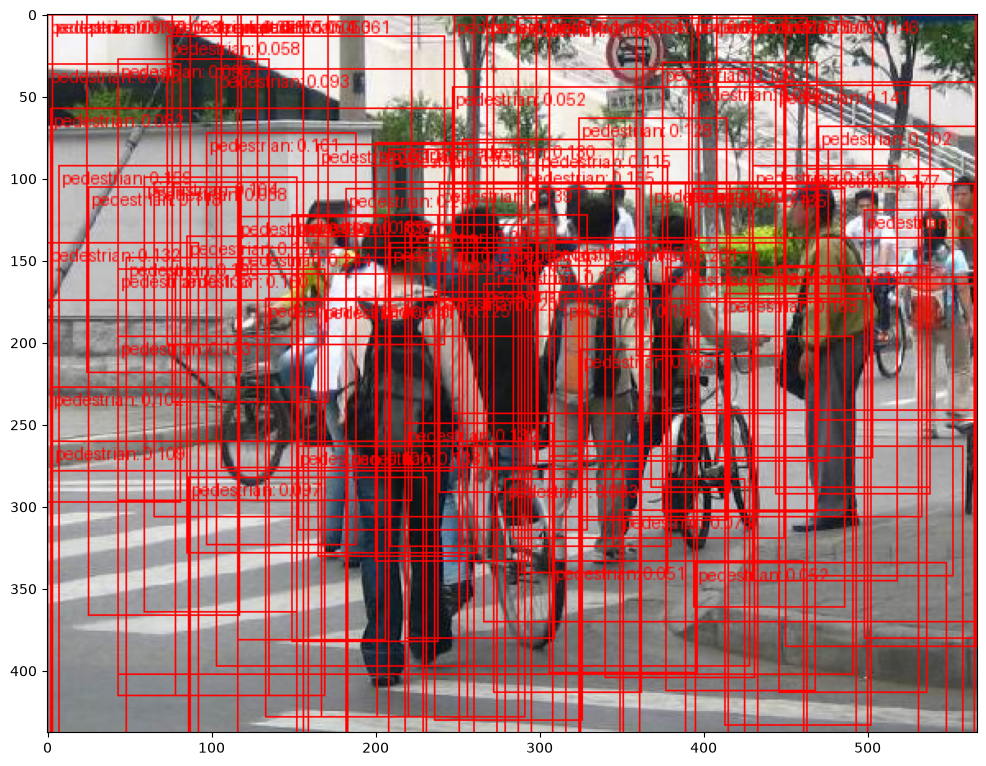

In [96]:
import matplotlib.pyplot as plt

from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks


image = read_image(base_path + "data/PennFudanPed/PNGImages/FudanPed00046.png")
eval_transform = get_transform(train=False)

model.eval()
with torch.no_grad():
    x = eval_transform(image)
    # convert RGBA -> RGB and move to device
    x = x[:3, ...].to(device)
    predictions = model([x, ])
    pred = predictions[0]


image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
image = image[:3, ...]
pred_labels = [f"pedestrian: {score:.3f}" for label, score in zip(pred["labels"], pred["scores"])]
pred_boxes = pred["boxes"].long()
output_image = draw_bounding_boxes(image, pred_boxes, pred_labels, colors="red")

masks = (pred["masks"] > 0.7).squeeze(1)
output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")


plt.figure(figsize=(12, 12))
plt.imshow(output_image.permute(1, 2, 0))